In [1]:
import os
import warnings

import duckdb
import pandas as pd
from uszipcode import SearchEngine

# from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")


In [2]:

path = r"C:\Users\bhavy\Massachusetts Institute of Technology\Truck Parking Capstone - General\Truck Stop Finder 🚚⛽\\"
# path = r"C:\Users\samcl\Massachusetts Institute of Technology\Truck Parking Capstone - Truck Stop Finder 🚚⛽\\"

In [3]:
sensor_loc = pd.read_csv(path + r"5. Source & Refrence Files\sensor_loc_w_ZIP5.csv",
                         dtype={"station_id": 'str', 'ZIP5': 'str'})
state_map = pd.read_csv(path + r"5. Source & Refrence Files\State_mapping.csv")
model_stop = pd.read_excel("output_excel/Model_Stops_V3.xlsx")
traffic_df = pd.read_csv(path + r"4. Working Data Files\Traffic Files\Capstone_truck\merged_filtered_modified.csv")


In [4]:
sensor_loc = sensor_loc[sensor_loc["State"] != "AK"].copy()

In [5]:
# search = SearchEngine()
#
# def get_zip(row):
#     r = search.by_coordinates(row['Latitude'], row['Longitude'], radius=60, returns=1)
#     return r[0].zipcode if r else None
#
# sensor_loc['ZIP5'] = sensor_loc.apply(get_zip, axis=1)

In [6]:
sensor_loc["ZIP3"] = sensor_loc["ZIP5"].str[:3]

In [7]:
sensor_loc.drop(columns="ZIP5", inplace=True)

In [8]:
sensor_loc.columns

Index(['Latitude', 'Longitude', 'Functional Class', 'State', 'Station Id',
       'ZIP3'],
      dtype='object')

In [9]:
# traffic_df["link_id"] = traffic_df["routeid"].astype("str") + "_" + traffic_df["beginpoint"].astype("str") + "_" + \
#                         traffic_df["endpoint"].astype("str")
# in_link = traffic_df[traffic_df["link_id"].isin(model_stop["link_id"].unique())][["link_id", "MID_LAT", "MID_LONG"]]
#
# sensor_stops = pd.merge(in_link, sensor_loc, how="cross")
#
# sensor_stops['distance_miles'] = haversine_vector(sensor_stops[['Latitude', 'Longitude']],
#                                                   sensor_stops[['MID_LAT', 'MID_LONG']],
#                                                   Unit.MILES
#                                                   ) * 1.16
#
# #Finding nearest road segment to every stop
# idx = sensor_stops.groupby('link_id')['distance_miles'].idxmin()
# nearest = sensor_stops.loc[idx].reset_index()
# nearest = nearest[['Latitude', 'Longitude', 'Functional Class', 'State', 'Station Id', 'link_id']].copy()
# nearest

In [10]:
# folder = path + r"5. Source & Refrence Files\2024_traffic_data"
# out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
# os.makedirs(out_dir, exist_ok=True)
#
# # build mapping dict ONCE from your state_map df
# state_dict = state_map.set_index("state_code")["State"].to_dict()
#
# id_var_col = [
#     'record_type', 'state_code', 'f_system', 'station_id', 'travel_dir',
#     'travel_lane', 'year_record', 'month_record', 'day_record',
#     'day_of_week', 'restrictions'
# ]
#
# part = 0
#
# for filename in os.listdir(folder):
#     file_path = os.path.join(folder, filename)
#
#     if not filename.lower().endswith(".zip"):
#         continue
#
#     print(f"Opening ZIP: {filename}")
#
#     with zipfile.ZipFile(file_path, 'r') as z:
#         for inner_name in z.namelist():
#             if inner_name.endswith("/"):
#                 continue
#
#             print(f"  Processing inside ZIP: {inner_name}")
#
#             with z.open(inner_name) as f:
#                 # Read CSV from inside the ZIP
#                 df = pd.read_csv(
#                     f,
#                     delimiter="|",
#                     low_memory=False  # avoids dtype warning at cost of some RAM, OK for chunk
#                     # You can also pass dtype={} here if you know them
#                 )
#
#                 # Melt wide hours columns into long format
#                 df = pd.melt(
#                     df,
#                     id_vars=id_var_col,
#                     var_name="hours",
#                     value_name="traffic"
#                 )
#
#                 # Add state_name via map instead of big merge later
#                 df["State"] = df["state_code"].map(state_dict)
#                 df["station_id"] = df["station_id"].astype(str)
#
#                 # Save this chunk to Parquet and drop from memory
#                 out_path = os.path.join(out_dir, f"traffic_part_{part}.parquet")
#                 df.to_parquet(out_path, index=False)
#                 # print(f"    → wrote {out_path}")
#
#                 del df
#                 part += 1
#
# print(f"Done. Wrote {part} parquet files to {out_dir}")


In [11]:
traffic_df = pd.DataFrame()

In [12]:
out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
traffic_parquet_glob = f"{out_dir}/traffic_part_*.parquet"

In [13]:
con = duckdb.connect()
con.register("sensor_loc", sensor_loc)

In [14]:
out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
traffic_parquet_glob = f"{out_dir}/traffic_part_*.parquet"

In [15]:
con.execute(f"""
    CREATE OR REPLACE TABLE traffic_matched AS
    SELECT
        t.*,                           -- all columns from traffic
        s.*
    FROM read_parquet('{traffic_parquet_glob}') AS t
    LEFT JOIN sensor_loc AS s
      ON t.station_id = s."Station Id"
     AND t.State      = s.State
    WHERE s."Latitude" IS NOT NULL
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [16]:
con.execute(f"""
    CREATE OR REPLACE TABLE traffic_unmatched  AS
    SELECT
        t.*,                           -- all columns from traffic
        s.*
    FROM read_parquet('{traffic_parquet_glob}') AS t
    LEFT JOIN sensor_loc AS s
      ON t.station_id = s."Station Id"
     AND t.State      = s.State
    WHERE s."Latitude" IS NULL
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [17]:
con.execute("""
            UPDATE traffic_unmatched
            SET station_id = ltrim(station_id, '0')
            """)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [18]:
# con.execute("""select *
#                from sensor_loc limit 5""").df()

In [19]:
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN Latitude')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN Longitude')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN "Functional Class"')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN State_1')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN "Station Id"')


In [20]:
con.execute("""select *
               from traffic_unmatched limit 5""").df()

,record_type,state_code,f_system,station_id,travel_dir,travel_lane,year_record,month_record,day_record,day_of_week,restrictions,hours,traffic,State,ZIP3
0,V,15,3U,2,1,1,2024,4,1,2,NaN,hour_00,22,HI,None
1,V,15,3U,2,1,1,2024,4,2,3,NaN,hour_00,27,HI,None
2,V,15,3U,2,1,1,2024,4,3,4,NaN,hour_00,25,HI,None
3,V,15,3U,2,1,1,2024,4,4,5,NaN,hour_00,20,HI,None
4,V,15,3U,2,1,1,2024,4,5,6,NaN,hour_00,34,HI,None


In [21]:
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN ZIP3')

In [22]:
con.execute("""
            INSERT INTO traffic_matched
            SELECT t.*,
                   s.*
            FROM traffic_unmatched t
                     LEFT JOIN sensor_loc s
                               ON t.station_id = s."Station Id"
                                   AND t.State = s.State
            WHERE s."Latitude" IS NOT NULL
            """)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [23]:
# con.execute("""
#             CREATE OR REPLACE TABLE traffic_unmatched  AS
#             SELECT t.*,
#                    s.*
#             FROM traffic_unmatched t
#                      LEFT JOIN sensor_loc s
#                                ON t.station_id = s."Station Id"
#                                    AND t.State = s.State
#             WHERE s."Latitude" IS NULL
#             """)

In [24]:
# con.execute("""select count(distinct station_id)
#                from traffic_unmatched """).df()

In [25]:
# con.execute("""select *
#                from traffic_matched LIMIT 5""").df()

In [26]:
# GA = con.execute("""select *
#                     from traffic_matched
#                     where station_id = '00R348'""").df()
#


In [27]:
# GA.to_csv('GA_Sensor_Data.csv', index=False)

In [28]:
# con.execute("""select distinct travel_lane
#                from traffic_matched
#             """).df()

In [29]:
# con.execute("""select *
#                from traffic_matched
#                where travel_lane = 7""").df()

In [30]:
# con.execute("""select *
#                from traffic_matched
#                where station_id = '860331'""").df().to_csv('FL_example.csv', index=False)

In [31]:
# con.execute(""" select station_id, state_code, count(distinct travel_dir)
#                 from traffic_matched
#                 group by station_id, state_code
#                 having count(distinct travel_dir) > 1""").df()

In [32]:
# con.execute("""select *
#                from traffic_matched
#                where station_id = '186'""").df().to_csv('186.csv', index=False)

In [33]:
# con.execute("""select distinct travel_dir
#                from traffic_matched
#             """).df()

In [34]:
con.execute("""CREATE OR REPLACE TABLE traffic_gp_matched  AS
            select record_type,state_code,f_system,station_id,travel_dir,year_record,month_record,day_record,day_of_week,restrictions,hours, sum(traffic) as "traffic_volume",State,Latitude,Longitude,"Functional Class",State_1,"Station Id",ZIP3, count(distinct travel_lane) as "lane_count"
               from traffic_matched
               group by record_type,state_code,f_system,station_id,travel_dir,year_record,month_record,day_record,day_of_week,restrictions,hours,State,Latitude,Longitude,"Functional Class",State_1,"Station Id",ZIP3
            """)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [39]:
con.execute("""select count(station_id)
               from traffic_gp_matched""").df()

,count(station_id)
0,102180672


In [40]:
# reg_df = con.execute("""select *
#                         from traffic_gp_matched
#                         where station_id = '186'
#                           and travel_dir = 3""").df()

In [41]:
# reg_df['hours'] = reg_df['hours'].str.replace('hour_', "").astype(int)

In [42]:
# reg_df.columns

In [43]:
con.execute("""select *
               from traffic_gp_matched limit 5""").df()

,record_type,state_code,f_system,station_id,travel_dir,year_record,month_record,day_record,day_of_week,restrictions,hours,traffic_volume,State,Latitude,Longitude,Functional Class,State_1,Station Id,ZIP3,lane_count
0,V,1,1R,87,7,2024,12,23,2,NaN,hour_14,649.0,AL,34.183617,-88.090580,1R,AL,87,355,2
1,V,1,1R,89,1,2024,12,14,7,NaN,hour_14,1490.0,AL,33.064494,-86.728588,1R,AL,89,350,2
2,V,1,1U,90,1,2024,12,19,5,NaN,hour_14,1953.0,AL,33.106889,-86.739504,1U,AL,90,350,3
3,V,1,1U,107,1,2024,12,12,5,NaN,hour_14,3102.0,AL,33.665017,-86.831461,1U,AL,107,350,4
4,V,1,1U,118,5,2024,12,11,4,NaN,hour_14,2618.0,AL,33.518978,-86.673937,1U,AL,118,352,3


In [44]:
df = con.execute("""select State_1,
                           ZIP3,
                           travel_dir,
                           day_of_week,
                           hours,
                           lane_count,
                           avg(traffic_volume)                          as avg_traffic,
                           median(traffic_volume),
                           stddev(traffic_volume),
                           stddev(traffic_volume) / avg(traffic_volume) as CV
                    from traffic_gp_matched
                    group by State_1, ZIP3, travel_dir, day_of_week, hours, lane_count""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [45]:
# df.to_csv("ZIP3_agg_data.csv", index=False)

In [41]:
df['delta'] = abs((df["avg(traffic_volume)"] - df["median(traffic_volume)"]) / df["avg(traffic_volume)"])
df

,State_1,ZIP3,travel_dir,day_of_week,hours,avg(traffic_volume),median(traffic_volume),stddev(traffic_volume),CV,delta
0,MA,016,7,2,hour_10,3028.647541,2902.0,768.326474,0.253686,0.041817
1,MA,017,7,2,hour_19,1547.768456,1207.0,653.252456,0.422061,0.220168
2,MA,015,3,3,hour_08,2531.421801,2851.0,1138.498566,0.449747,0.126245
3,MA,016,3,5,hour_08,3875.060790,4116.0,1007.347269,0.259957,0.062177
4,GA,310,1,6,hour_19,520.145695,328.5,533.839710,1.026327,0.368446
...,...,...,...,...,...,...,...,...,...,...
538915,NY,114,7,2,hour_09,3894.000000,3894.0,NaN,NaN,0.000000
538916,TX,777,7,5,hour_21,747.000000,747.0,NaN,NaN,0.000000
538917,TX,777,7,3,hour_08,2011.000000,2011.0,NaN,NaN,0.000000
538918,TX,777,3,4,hour_13,2384.000000,2384.0,NaN,NaN,0.000000


In [42]:
import matplotlib.pyplot as plt

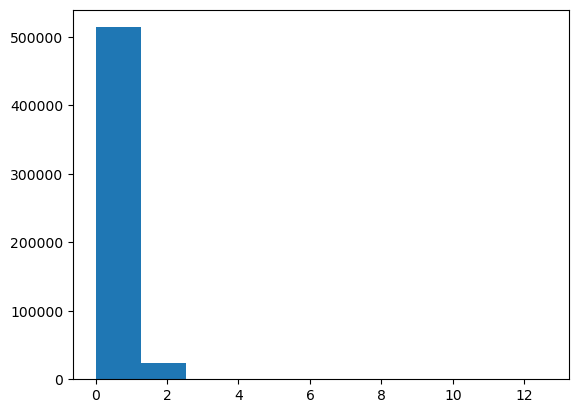

In [43]:
plt.hist(df["CV"])

plt.show()

In [44]:
df['delta'].describe()

count    538887.000000
mean          0.202192
std           0.221560
min           0.000000
25%           0.029046
50%           0.110958
75%           0.314761
max           1.000000
Name: delta, dtype: float64

In [45]:
df['CV'].describe()

count    538504.000000
mean          0.597548
std           0.398777
min           0.000000
25%           0.270998
50%           0.564533
75%           0.833612
max          12.615563
Name: CV, dtype: float64

In [46]:
df[df['delta'] == 1]

,State_1,ZIP3,travel_dir,day_of_week,hours,avg(traffic_volume),median(traffic_volume),stddev(traffic_volume),CV,delta
95,NE,686,7,4,hour_04,0.568627,0.0,0.938820,1.651028,1.0
682,MT,593,1,6,hour_03,0.703226,0.0,1.057897,1.504348,1.0
876,IA,501,9,7,hour_01,0.352941,0.0,0.626850,1.776076,1.0
2266,NE,683,7,3,hour_02,0.180000,0.0,0.437526,2.430697,1.0
2724,MT,593,1,1,hour_02,0.769737,0.0,1.947899,2.530604,1.0
...,...,...,...,...,...,...,...,...,...,...
538062,VT,037,5,7,hour_02,0.705882,0.0,0.970143,1.374369,1.0
538130,IA,522,0,6,hour_04,0.086957,0.0,0.354406,4.075673,1.0
538649,ID,978,2,6,hour_04,0.214286,0.0,0.470377,2.195092,1.0
538731,NC,281,7,4,hour_01,0.820000,0.0,1.082137,1.319679,1.0


In [47]:
# Get the ZIP5 in truck data
# Check which ZIP5 in truck doesn't exist in sensor file
# If doesn't exist, either find the nearest one, or take ZIP3

In [48]:
search = SearchEngine()


def get_zip(row):
    r = search.by_coordinates(row['lat'], row['lng'], radius=30, returns=1)
    return r[0].zipcode if r else None


model_stop['ZIP5'] = model_stop.apply(get_zip, axis=1)

In [50]:
model_stop['ZIP3'] = model_stop['ZIP5'].str[:3]

In [51]:
model_stop[~model_stop["ZIP3"].isin(df["ZIP3"].unique())]

,pin id,pinname,lat,lng,truckParkingSpotCount,f_system,link_id,review_score,amenities_score,overnightParking,ZIP5,ZIP3
199,03be69ebd320098561a58ad581bb23b1,Molly's Food & Fuel - PTP Stop,33.508993,-82.448267,20,1,1000100040200INC_175.166_175.266,NaN,NaN,1.0,30824,308
209,0e139b17a92b2df7d6c3c840e51465fe,Chevron,33.513145,-82.445004,69,1,1000100040200INC_175.3026_175.392,NaN,NaN,1.0,30824,308
256,5151500c7abdd9f9b0c784dcff2ef015,"TA Express Thomson, GA.",33.509622,-82.450100,75,1,1000100040200INC_175.066_175.166,NaN,NaN,1.0,30824,308
274,5ff7ecaff37941d43cdefd26811124de,Rest Area #63 I-20 Westbound,33.499568,-82.327878,1,1,1000100040200INC_182.188_182.288,NaN,NaN,1.0,30814,308
294,7eb0e9aab7876f4b801e76da5084759b,Rest Area EB,33.497897,-82.335754,40,1,1000100040200INC_181.688_181.788,NaN,NaN,1.0,30814,308
378,d6723e7cd6735df68d1ce4c704c29a04,Love's Travel Stop # 354,33.514228,-82.503612,79,3,1000100001700INC_143.775_143.875,NaN,NaN,1.0,30824,308
389,ddf88ea64eaed0f3de5531ac964a0a1a,LUCKY LAND TRAVEL PLAZA,33.309252,-82.196154,20,3,1000100054000INC_200.314_200.414,NaN,NaN,1.0,30805,308
400,ecffa906ccd2b531f26200e9a264442b,Jet Gas & Food,33.407698,-82.653960,5,1,1000100040200INC_163.021_163.121,NaN,NaN,0.0,30828,308
415,faf305d20c6e75a1b675d0509be63046,AM-PM TRAVEL CENTER,33.329363,-82.170510,20,3,1000100054000INC_202.414_202.514,NaN,NaN,1.0,30805,308


In [53]:
df[df["ZIP3"] == "307"]

,State_1,ZIP3,travel_dir,day_of_week,hours,avg(traffic_volume),median(traffic_volume),stddev(traffic_volume),CV,delta
42,GA,307,1,5,hour_16,807.711538,463.5,848.430186,1.050412,0.426157
1326,GA,307,5,1,hour_14,892.926070,446.0,1087.233997,1.217608,0.500519
2083,GA,307,3,6,hour_06,1289.300971,1147.0,348.255086,0.270112,0.110371
3361,GA,307,5,3,hour_23,211.746212,91.0,296.408964,1.399831,0.570240
3993,GA,307,1,6,hour_14,866.799228,472.0,958.685994,1.106007,0.455468
...,...,...,...,...,...,...,...,...,...,...
533340,GA,307,3,1,hour_09,1340.769231,1321.5,270.325666,0.201620,0.014372
534652,GA,307,7,7,hour_04,372.596154,361.5,80.846675,0.216982,0.029781
535089,GA,307,7,6,hour_21,1212.242718,1192.0,300.135801,0.247587,0.016699
535554,GA,307,1,1,hour_12,828.408560,444.0,963.128014,1.162624,0.464033
